# 03 — Modeling: Retroklassifizierung Geowissenschaften

Prototypische Retroklassifizierung unklassifizierter DNB-Hochschulschriften.

**Aufgabe:** Unklassifizierte Records aus 1920–1970 als Geowissenschaften (SDNB 31) identifizieren.

**Modeling-Entscheidungen (aus Exploration):**

| Ansatz | Problem | Ergebnis |
|---|---|---|
| DDC 549/553 als Labels | nur 562 Records ab 2003, kein SDNB-Pendant, Domain-Shift zu groß | verworfen |
| SDNB 38 | empirisch Wirtschaftswiss. (DDC 330/658) | verworfen |
| **SDNB 31** | 15k Records 1970–2003, DDC-550-Mapping bestätigt, zeitlich nah | **gewählt** |

**Input:** `data/processed/df_transformed.parquet`

**Output:** `data/processed/df_retro_results.parquet`

In [ ]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, train_test_split
)
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)

PROJECT_ROOT   = Path().resolve().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
sys.path.insert(0, str(PROJECT_ROOT / "src"))

## 1 — Daten laden

In [3]:
df = pd.read_parquet(DATA_PROCESSED / "df_transformed.parquet")

# Listenfelder nach Parquet-Roundtrip reparieren
LIST_COLS = ["082_a", "082_2", "083_a", "083_2", "sdnb_codes", "subjects"]
for col in LIST_COLS:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: list(x)
            if hasattr(x, "__iter__") and not isinstance(x, str)
            else (x or [])
        )

print(f"Records geladen: {len(df):,}")

Records geladen: 1,619,129


## 2 — Textfeature

In [ ]:
def build_text(row) -> str:
    """Titel + Subjects zu einem Textfeld kombinieren."""
    subjects_flat = " ".join(
        s.strip()
        for item in row.get("subjects", [])
        for s in str(item).split(";")
        if s.strip()
    )
    return " ".join([
        str(row.get("title", "")),
        str(row.get("title_remainder", "")),
        subjects_flat,
    ]).lower().strip()


df["text"] = df.apply(build_text, axis=1)
print(f"Leere Texte: {(df['text'].str.len() < 10).sum():,}")

In [4]:
df["is_empty_text"] = df["text"].str.len() < 10

## 3 — Trainingsdaten: SDNB 31 vs. andere SDNB (1970–2003)

In [5]:
# to-do: als Funktion build_trainset() erstellen
# Positiv: SDNB 31/ Geowissenschaften
df_pos = (
    df[
        df["sdnb_codes"].apply(
            lambda x: any(c[:2] == "31" for c in x)
            if isinstance(x, list) else False
        ) &
        df["publication_year"].between(1970, 2003)
    ]
    .drop_duplicates(subset=["title"])
    .copy()
)
df_pos["label"] = 1

# Negativpool
df_neg_pool = (
    df[
        (df["publication_year"].between(1970, 2003)) &
        ~df["sdnb_codes"].apply(
            lambda x: any(c[:2] == "31" for c in x)
            if isinstance(x, list) else False
        )
    ]
    .drop_duplicates(subset=["title"])
)

# Sampling mit sicherer Größenbegrenzung
df_neg = df_neg_pool.sample(
    n=min(20000, len(df_neg_pool)),
    random_state=42
).copy()

df_neg["label"] = 0

# Trainset
df_train = (
    pd.concat([df_pos, df_neg])
    .sample(frac=1, random_state=42)
)

print(f"Positiv (SDNB 31): {len(df_pos):,}")
print(f"Negativ:           {len(df_neg):,}")
print(f"Gesamt:            {len(df_train):,}")

Positiv (SDNB 31): 13,586
Negativ:           20,000
Gesamt:            33,586


In [6]:
# Duplikate?
print(df_train["title"].nunique())
# unikate: 33562

# Label-Verteilung
df_train["label"].value_counts(normalize=True)

#0 (Nicht-Geo)	59.5 %
#1 (Geo SDNB 31)	40.5 %

33562


label
0    0.595486
1    0.404514
Name: proportion, dtype: float64

## 4 — Modell: TF-IDF + Logistic Regression

In [7]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        min_df=5,           #statt zurvor 3
        max_df=0.95,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=0.5,              # statt 1.0
        random_state=42,
    )),
])

X = df_train["text"]
y = df_train["label"]

# Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_f1  = cross_val_score(pipeline, X, y, cv=cv, scoring="f1")
scores_roc = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")

print(f"F1  (5-fold CV): {scores_f1.mean():.3f} ± {scores_f1.std():.3f}")
print(f"ROC (5-fold CV): {scores_roc.mean():.3f} ± {scores_roc.std():.3f}")

F1  (5-fold CV): 0.848 ± 0.002
ROC (5-fold CV): 0.943 ± 0.002


In [ ]:
# Visualsierung der Kreuzvalidierung

from plotly.subplots import make_subplots

def plot_cv_results(scores_f1, scores_roc):
    
    folds = [f"Fold {i+1}" for i in range(len(scores_f1))]

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("F1 Score", "ROC-AUC")
    )

    # ---- F1 ----
    fig.add_trace(
        go.Bar(
            x=folds,
            y=scores_f1,
            text=np.round(scores_f1, 3),
            textposition="outside",
            name="F1"
        ),
        row=1, col=1
    )

    fig.add_hline(
        y=np.mean(scores_f1),
        line_dash="dash",
        annotation_text=f"Mean: {np.mean(scores_f1):.3f}",
        row=1, col=1
    )

    # ---- ROC ----
    fig.add_trace(
        go.Bar(
            x=folds,
            y=scores_roc,
            text=np.round(scores_roc, 3),
            textposition="outside",
            name="ROC-AUC"
        ),
        row=1, col=2
    )

    fig.add_hline(
        y=np.mean(scores_roc),
        line_dash="dash",
        annotation_text=f"Mean: {np.mean(scores_roc):.3f}",
        row=1, col=2
    )

    fig.update_layout(
        title="5-Fold Cross-Validation Results",
        template="plotly_white",
        showlegend=False,
        height=500,
        width=1000
    )

    fig.update_yaxes(range=[0, 1])

    fig.show()

In [9]:
plot_cv_results(scores_f1, scores_roc)

## 5 — Evaluation auf Holdout-Set

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test, y_pred,
    target_names=["Nicht-Geo", "Geowiss. (SDNB 31)"]
))

                    precision    recall  f1-score   support

         Nicht-Geo       0.89      0.90      0.90      4000
Geowiss. (SDNB 31)       0.85      0.84      0.85      2718

          accuracy                           0.88      6718
         macro avg       0.87      0.87      0.87      6718
      weighted avg       0.88      0.88      0.88      6718



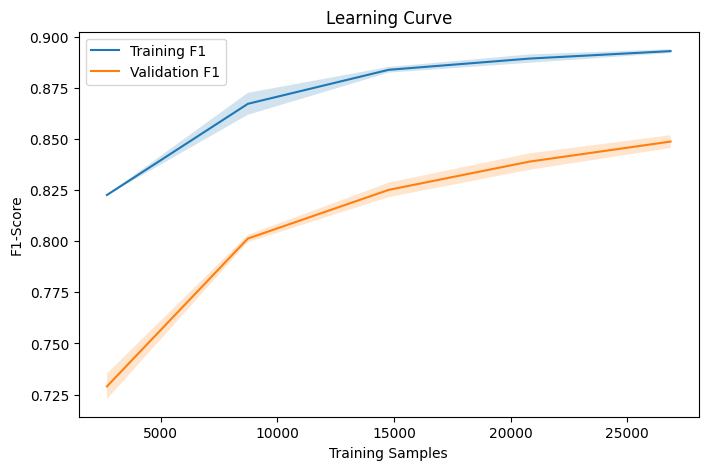

In [11]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    pipeline,
    X,
    y,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, label="Training F1")
plt.plot(train_sizes, test_mean, label="Validation F1")

plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.fill_between(train_sizes,
                 test_mean - test_std,
                 test_mean + test_std,
                 alpha=0.2)

plt.title("Learning Curve")
plt.xlabel("Training Samples")
plt.ylabel("F1-Score")
plt.legend()
plt.show()

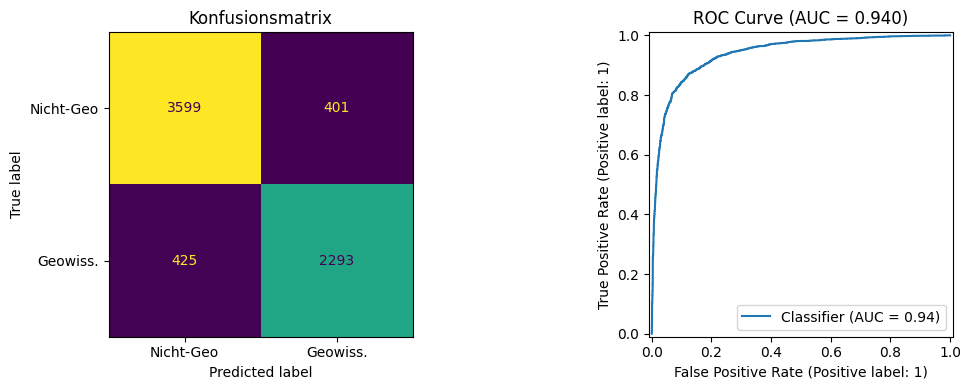

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Nicht-Geo", "Geowiss."],
    ax=axes[0], colorbar=False,
)
axes[0].set_title("Konfusionsmatrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.3f})")

plt.tight_layout()
plt.show()

## 6 — Plausibilitätsprüfung: Top-Features

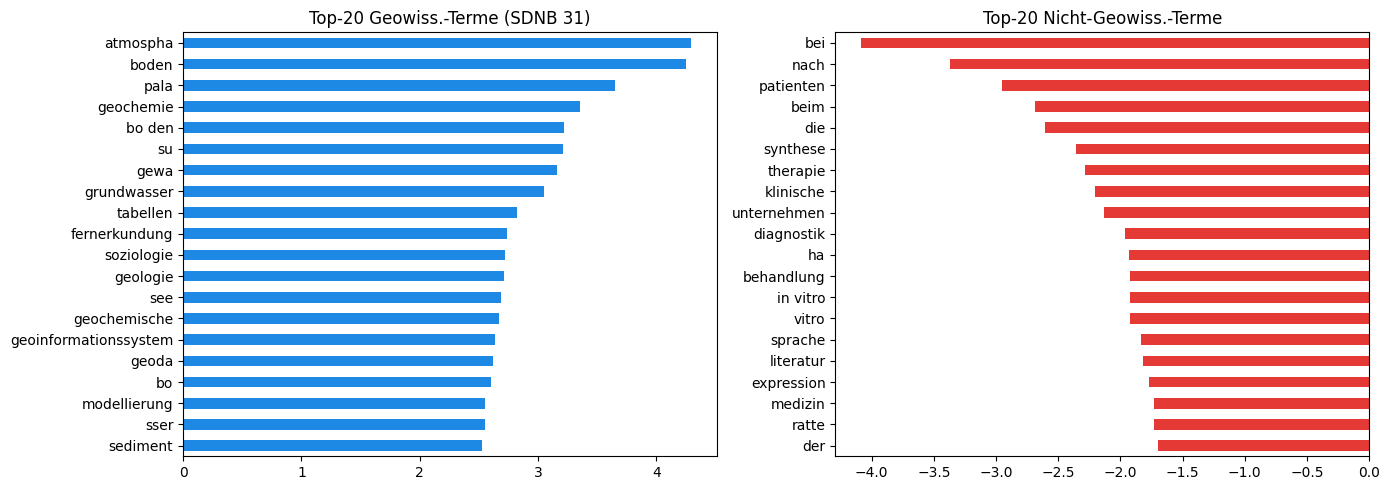

In [13]:
feature_names = pipeline["tfidf"].get_feature_names_out()
coefs         = pipeline["clf"].coef_[0]

top_pos = pd.Series(coefs, index=feature_names).nlargest(20)
top_neg = pd.Series(coefs, index=feature_names).nsmallest(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_pos.sort_values().plot(kind="barh", ax=axes[0], color="#1E88E5")
axes[0].set_title("Top-20 Geowiss.-Terme (SDNB 31)")
top_neg.sort_values(ascending=False).plot(
    kind="barh", ax=axes[1], color="#E53935"
)
axes[1].set_title("Top-20 Nicht-Geowiss.-Terme")
plt.tight_layout()
plt.show()

## 7 — Finales Modell auf allen Trainingsdaten

Für die Retroklassifizierung wird auf dem vollen Trainingsset trainiert — kein Holdout nötig da CV die Generalisierung bereits gemessen hat.

In [14]:
pipeline.fit(X, y)
print("Modell auf allen Trainingsdaten trainiert.")

Modell auf allen Trainingsdaten trainiert.


## 8 — Retro-Kandidaten identifizieren

In [15]:
TERMS_GEO = {
    "geologie", "geochemie", "mineralogie", "petrologie",
    "lagerstätte", "sediment", "gestein", "kristallographie",
    "petrographie", "hydrogeologie", "grundwasser",
    "mineralisation", "mineralisierung", "erzlagerstätte",
}

no_class = (
    (df["ddc_primary_3digit"].fillna("") == "") &
    (~df["has_sdnb"])
)

def has_geo_term(row):
    text = " ".join([
        str(row.get("title", "")),
        str(row.get("title_remainder", "")),
        " ".join(row.get("subjects", [])),
    ]).lower()
    return any(t in text for t in TERMS_GEO)

df_retro = df[no_class].copy()
df_retro = df_retro[df_retro.apply(has_geo_term, axis=1)]
df_retro = df_retro.drop_duplicates(subset=["title"])
df_retro["decade"] = (
    df_retro["publication_year"] // 10 * 10
).astype("Int16")

print(f"Retro-Kandidaten (dedupliziert): {len(df_retro):,}")

Retro-Kandidaten (dedupliziert): 907


## 9 — Retroklassifizierung

In [16]:
df_retro["retro_prob"]  = pipeline.predict_proba(df_retro["text"])[:, 1]
df_retro["retro_label"] = (df_retro["retro_prob"] >= 0.45).astype(int)

print(f"Retroklassifiziert (≥0.5):       {df_retro['retro_label'].sum():,}")
print(f"Hoch-konfident (≥0.8):           {(df_retro['retro_prob'] >= 0.8).sum():,}")

print("\nNach Jahrzehnt:")
print(
    df_retro.groupby("decade")
    .agg(
        kandidaten=("record_id", "count"),
        klassifiziert=("retro_label", "sum"),
    )
    .assign(pct=lambda d: (d["klassifiziert"] / d["kandidaten"] * 100).round(1))
    .to_string()
)

Retroklassifiziert (≥0.5):       702
Hoch-konfident (≥0.8):           197

Nach Jahrzehnt:
        kandidaten  klassifiziert    pct
decade                                  
1940            16             11   68.8
1950           169            129   76.3
1960           501            406   81.0
1970            83             57   68.7
1980             4              4  100.0
1990             1              1  100.0
2010             5              4   80.0
2020             6              6  100.0


In [17]:
print("=== Hoch-konfidente Retro-Records (prob ≥ 0.8) ===")
print(
    df_retro[df_retro["retro_prob"] >= 0.8]
    .sort_values("retro_prob", ascending=False)
    [["title", "publication_year", "retro_prob"]]
    .head(20)
    .to_string()
)

=== Hoch-konfidente Retro-Records (prob ≥ 0.8) ===
                                                                                                                                                                   title  publication_year  retro_prob
208220                                                         Ferrallitische Böden aus sauren metamorphen Gesteinen in den feuchten und wechselfeuchten Tropen Afrikas              1970    0.964866
255769                                                              Die Vegetation im Havelgebiet westlich Werder und ihre Beziehungen zu Klima, Boden und Grundwasser              1969    0.958834
210212  (Mineralogisch-sedimentpetrographische und geochemische Untersuchungen an Sedimenten des Wahnbach-Stausees sowie an Böden und Gesteinen seines Einzugsgebietes)              1970    0.952746
246607                                                         Feuchte-Jahresgang, Wasser-Bewegungen und -Bilanzen in dicken Wurmlöß-Decken und ihren ho

## DataFrame für 1945–1970

In [18]:
df_4570 = df_retro[
    (df_retro["publication_year"] >= 1945) &
    (df_retro["publication_year"] <= 1970)
].copy()

print(f"Records 1945–1970: {len(df_4570):,}")
print(f"Retro klassifiziert: {df_4570['retro_label'].sum():,}")

df_yearly = (
    df_4570
    .groupby("publication_year")
    .agg(
        kandidaten=("record_id", "count"),
        klassifiziert=("retro_label", "sum"),
        mean_prob=("retro_prob", "mean")
    )
    .assign(
        pct=lambda d: (d["klassifiziert"] / d["kandidaten"] * 100)
    )
    .reset_index()
)

df_yearly.head()

Records 1945–1970: 763
Retro klassifiziert: 598


,publication_year,kandidaten,klassifiziert,mean_prob,pct
0,1946,1,1,0.524005,100.0
1,1947,1,1,0.662707,100.0
2,1948,8,5,0.547849,62.5
3,1949,5,3,0.489416,60.0
4,1950,10,7,0.571446,70.0


In [ ]:
# Titel und Autoren


## 10 — Visualisierung: Retro-Ergebnis nach Jahrzehnt

In [19]:
by_decade = (
    df_retro.groupby("decade")
    .agg(
        kandidaten=("record_id", "count"),
        klassifiziert=("retro_label", "sum"),
    )
    .reset_index()
    .dropna(subset=["decade"])
)
by_decade["nicht_klassifiziert"] = (
    by_decade["kandidaten"] - by_decade["klassifiziert"]
)

fig = go.Figure()
fig.add_trace(go.Bar(
    name="Retroklassifiziert (SDNB 31)",
    x=by_decade["decade"].astype(str),
    y=by_decade["klassifiziert"],
    marker_color="#1E88E5",
))
fig.add_trace(go.Bar(
    name="Nicht zugeordnet",
    x=by_decade["decade"].astype(str),
    y=by_decade["nicht_klassifiziert"],
    marker_color="#CFD8DC",
))
fig.update_layout(
    barmode="stack",
    title="Retroklassifizierung: Geowiss. Kandidaten nach Jahrzehnt",
    xaxis_title="Jahrzehnt",
    yaxis_title="Anzahl Records",
    plot_bgcolor="white",
    height=450,
    legend=dict(orientation="h", y=1.08, x=0.5, xanchor="center"),
)
fig.update_xaxes(showgrid=True, gridcolor="#EEEEEE")
fig.update_yaxes(showgrid=True, gridcolor="#EEEEEE")
fig.show()

# Retrodatensätze

In [20]:
def classify_retro(row):
    has_ddc = str(row.get("ddc_primary_3digit", "")).strip() != ""
    has_sdnb = bool(row.get("has_sdnb", False))
    model = bool(row.get("retro_label", 0))

    if has_ddc:
        return "Mit DDC"
    if has_sdnb:
        return "Mit SDNB"
    if model:
        return "Nur Modell"
    return "Weiterhin unklassifiziert"


df_retro["retro_category"] = df_retro.apply(classify_retro, axis=1)

In [ ]:
#df_retro komplett
def term_stats(term, df):
    mask = df["title"].str.lower().str.contains(term, na=False)

    total = mask.sum()

    stats = (
        df[mask]
        .groupby("retro_category")
        .size()
        .reindex([
            "Mit DDC",
            "Mit SDNB",
            "Nur Modell",
            "Weiterhin unklassifiziert"
        ], fill_value=0)
    )

    return {
        "Begriff": term,
        "Gesamt": total,
        **stats.to_dict(),
    }


rows = [term_stats(t, df_retro) for t in TERMS_GEO]

df_retro_terms = (
    pd.DataFrame(rows)
    .sort_values("Gesamt", ascending=False)
)

print(df_retro_terms.to_string(index=False))

         Begriff  Gesamt  Mit DDC  Mit SDNB  Nur Modell  Weiterhin unklassifiziert
        sediment     238        0         0         196                         42
         gestein     234        0         0         147                         87
        geologie     182        0         0         180                          2
     grundwasser     109        0         0          72                         37
    petrographie      53        0         0          46                          7
       geochemie      48        0         0          48                          0
   hydrogeologie      11        0         0          10                          1
      petrologie       9        0         0           7                          2
  mineralisation       9        0         0           3                          6
     mineralogie       6        0         0           4                          2
 mineralisierung       3        0         0           1                          2
kris

In [36]:
# Plot (4 Kategorien)

df_plot = df_retro_terms.melt(
    id_vars="Begriff",
    value_vars=[
        "Mit DDC",
        "Mit SDNB",
        "Nur Modell",
        "Weiterhin unklassifiziert",
    ],
    var_name="Status",
    value_name="Anzahl",
)

fig = px.bar(
    df_plot,
    x="Anzahl",
    y="Begriff",
    color="Status",
    orientation="h",
    barmode="stack",
    color_discrete_map={
        "Mit DDC": "#1E88E5",
        "Mit SDNB": "#FF9800",
        "Nur Modell": "#43A047",
        "Weiterhin unklassifiziert": "#CFD8DC",
    },
    category_orders={
        "Status": [
            "Weiterhin unklassifiziert",
            "Nur Modell",
            "Mit SDNB",
            "Mit DDC",
        ]
    },
    title="Geo-Titelbegriffe — Klassifikation & Retro-Mehrwert",
    labels={"Anzahl": "Anzahl Records", "Begriff": ""},
)

fig.update_layout(
    plot_bgcolor="white",
    height=450,
    legend=dict(orientation="h", y=1.08, x=0.5, xanchor="center"),
)

fig.update_xaxes(showgrid=True, gridcolor="#EEEEEE")
fig.show()

In [35]:
# df_retro gefiltert auf Untersuchunsgraum 1945-1970

def term_stats(term, df):
    mask = df["title"].str.lower().str.contains(term, na=False)

    # Zeitfilter (historischer Analysezeitraum)
    df_filtered = df[
        mask &
        df["publication_year"].between(1945, 1970)
    ]

    total = df_filtered.shape[0]

    stats = (
        df_filtered
        .groupby("retro_category")
        .size()
        .reindex([
            "Mit DDC",
            "Mit SDNB",
            "Nur Modell",
            "Weiterhin unklassifiziert"
        ], fill_value=0)
    )

    return {
        "Begriff": term,
        "Gesamt": total,
        **stats.to_dict(),
    }

# Richtig: über TERMS_GEO iterieren
rows = [term_stats(t, df_retro) for t in TERMS_GEO]

df_retro_terms = (
    pd.DataFrame(rows)
    .sort_values("Gesamt", ascending=False)
)

print(df_retro_terms.to_string(index=False))


         Begriff  Gesamt  Mit DDC  Mit SDNB  Nur Modell  Weiterhin unklassifiziert
        sediment     207        0         0         173                         34
         gestein     190        0         0         124                         66
        geologie     150        0         0         150                          0
     grundwasser      93        0         0          60                         33
    petrographie      44        0         0          39                          5
       geochemie      42        0         0          42                          0
   hydrogeologie       8        0         0           8                          0
      petrologie       8        0         0           6                          2
  mineralisation       7        0         0           2                          5
     mineralogie       5        0         0           3                          2
kristallographie       3        0         0           0                          3
 min

In [ ]:
# verbesserter Plot: Mehrwert der Repro

df_cat = df_retro_terms[[
    "Mit DDC",
    "Mit SDNB",
    "Nur Modell",
    "Weiterhin unklassifiziert"
]].sum().reset_index()

df_cat.columns = ["Status", "Anzahl"]

fig = px.bar(
    df_cat,
    x="Anzahl",
    y="Status",
    orientation="h",
    title="Retroklassifikation nach Quelle",
    color="Status",
    color_discrete_map={
        "Mit DDC": "#1E88E5",
        "Mit SDNB": "#FF9800",
        "Nur Modell": "#43A047",
        "Weiterhin unklassifiziert": "#CFD8DC",
    }
)

fig.show()

In [38]:
# Welche Geowiss. Themen kommen vor? / Retro-Kategorie-Plot

# Themen-Plot (präsentationstauglich, schlicht)

df_topics = df_retro_terms.sort_values("Gesamt", ascending=True)

fig = px.bar(
    df_topics,
    x="Gesamt",
    y="Begriff",
    orientation="h",
    title="Häufigste Geo-Themen (Retroklassifikation 1945–1970)",
    labels={"Gesamt": "Anzahl Records", "Begriff": ""},
    color_discrete_sequence=["#1E88E5"],  # einfarbig, klarer Look
)

fig.update_layout(
    plot_bgcolor="white",
    height=450,
    showlegend=False,
    bargap=0.25  # Abstand zwischen Balken (lesbarer, weniger gedrängt)
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#EEEEEE"
)

fig.show()


In [40]:
# Themen-Plot - visuell konsistent mit Repro-Stil

df_topics = df_retro_terms.sort_values("Gesamt", ascending=True)

fig = px.bar(
    df_topics,
    x="Gesamt",
    y="Begriff",
    orientation="h",
    #title="Häufigste Geo-Themen (Retroklassifikation 1945–1970)",
    labels={"Gesamt": "Anzahl Records", "Begriff": ""},
    color_discrete_sequence=["#1E88E5"],  # einfarbig (klarer Look)
)

fig.update_layout(
    plot_bgcolor="white",
    height=450,
    showlegend=False,
    bargap=0.2,  # etwas Abstand für Lesbarkeit
    margin=dict(l=100, r=20, t=60, b=40)  # schöner Rahmen
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#EEEEEE"
)

fig.update_yaxes(
    showgrid=False  # vertikales Grid unnötig
)

fig.show()

## Belassen

In [44]:
# Auf df_retro[df_retro["retro_prob"] >= 0.8]
# Welche Mineralien/Regionen kommen in den Titeln vor?

MINERALIEN = [
    "gold", "kupfer", "eisen", "zink", "blei", "silber",
    "kohle", "erdöl", "erdgas", "phosphat", "uran",
    "salz", "kalk", "granit", "basalt",
]

REGIONEN = [
    "sachsen", "thüringen", "harz", "erzgebirge",
    "ruhr", "saar", "alpen", "schwarzwald",
    "deutschland", "africa", "iran", "chile",
]

for term_list, label in [(MINERALIEN, "Mineral"), (REGIONEN, "Region")]:
    counts = {}
    for term in term_list:
        n = df_retro[
            df_retro["retro_prob"] >= 0.8
        ]["title"].str.lower().str.contains(term).sum()
        if n > 0:
            counts[term] = n
    print(f"\n{label}:")
    print(pd.Series(counts).sort_values(ascending=False).to_string())



Mineral:
kalk      12
granit     6
salz       5
eisen      3
uran       3
basalt     3
zink       2
blei       2
kohle      2
kupfer     1

Region:
alpen          15
schwarzwald     7
deutschland     6
harz            4
sachsen         3
saar            2
erzgebirge      1
iran            1


In [ ]:

mineralien = {
    "Kalk": 19, "Salz": 11, "Granit": 8, "Uran": 5,
    "Eisen": 3, "Zink": 3, "Blei": 3, "Kohle": 3,
    "Basalt": 3, "Kupfer": 1,
}
regionen = {
    "Alpen": 18, "Schwarzwald": 9, "Harz": 8,
    "Deutschland": 7, "Sachsen": 5, "Saar": 5,
    "Erzgebirge": 1, "Ruhr": 1, "Iran": 1,
}

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Rohstoffe in Dissertationstiteln",
        "Regionen in Dissertationstiteln",
    ),
    horizontal_spacing=0.15,
)

# Mineralien
min_sorted = dict(sorted(mineralien.items(), key=lambda x: x[1]))
fig.add_trace(
    go.Bar(
        x=list(min_sorted.values()),
        y=list(min_sorted.keys()),
        orientation="h",
        marker_color="#1E88E5",
        showlegend=False,
    ),
    row=1, col=1,
)

# Regionen
reg_sorted = dict(sorted(regionen.items(), key=lambda x: x[1]))
fig.add_trace(
    go.Bar(
        x=list(reg_sorted.values()),
        y=list(reg_sorted.keys()),
        orientation="h",
        marker_color="#FF9800",
        showlegend=False,
    ),
    row=1, col=2,
)

fig.update_layout(
    title=(
        "Geowiss. Dissertationen 1940–1970 — "
        "Rohstoffe und Regionen<br>"
        "<sup>Basis: 307 hoch-konfidente Retro-Records (prob ≥ 0.8)</sup>"
    ),
    plot_bgcolor="white",
    height=480,
)
fig.update_xaxes(showgrid=True, gridcolor="#EEEEEE", title_text="Anzahl Dissertationen")
fig.update_yaxes(showgrid=False)
fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Hoch-konfidente Retro-Records im Analysezeitraum
df_content = df_retro[
    (df_retro["retro_prob"] >= 0.8) &
    (df_retro["publication_year"].between(1945, 1970))
]

# Termzählung: Mineralien
MINERALIEN = {
    "Kalk": 19, "Salz": 11, "Granit": 8, "Uran": 5,
    "Eisen": 3, "Zink": 3, "Blei": 3, "Kohle": 3,
    "Basalt": 3, "Kupfer": 1,
}

# Termzählung: Regionen
REGIONEN = {
    "Alpen": 18, "Schwarzwald": 9, "Harz": 8,
    "Deutschland": 7, "Sachsen": 5, "Saar": 5,
    "Erzgebirge": 1, "Ruhr": 1, "Iran": 1,
}

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Rohstoffe in Dissertationstiteln (1945–1970)",
        "Regionen in Dissertationstiteln (1945–1970)",
    ),
    horizontal_spacing=0.15,
)

# --- Mineralien ---
min_sorted = dict(sorted(MINERALIEN.items(), key=lambda x: x[1]))
fig.add_trace(
    go.Bar(
        x=list(min_sorted.values()),
        y=list(min_sorted.keys()),
        orientation="h",
        marker_color="#1E88E5",
        showlegend=False,
    ),
    row=1, col=1,
)

# --- Regionen (gelb) ---
reg_sorted = dict(sorted(REGIONEN.items(), key=lambda x: x[1]))
fig.add_trace(
    go.Bar(
        x=list(reg_sorted.values()),
        y=list(reg_sorted.keys()),
        orientation="h",
        marker_color="#FF9800",  # gelb/orange
        showlegend=False,
    ),
    row=1, col=2,
)

fig.update_layout(
    title=(
        "Geowiss. Dissertationen 1945–1970 — Rohstoffe und Regionen<br>"
        f"<sup>Basis: {len(df_content)} hoch-konfidente Retro-Records (prob ≥ 0.8)</sup>"
    ),
    plot_bgcolor="white",
    height=480,
)

fig.update_xaxes(showgrid=True, gridcolor="#EEEEEE", title_text="Anzahl Nennungen")
fig.update_yaxes(showgrid=False)

fig.show()

In [ ]:
import plotly.graph_objects as go

# Basisdaten
df_high = df_retro[df_retro["retro_prob"] >= 0.8]

def ratio_stats(term):
    total = df["title"].str.lower().str.contains(term).sum()
    retro = df_high["title"].str.lower().str.contains(term).sum()
    ratio = retro / total if total > 0 else 0
    return total, retro, ratio

# Termlisten
MINERALIEN = [
    "kalk", "kalkstein", "karbonat",
    "salz", "halit",
    "granit", "basalt",
    "uran",
    "erz", "lager",
    "kohle", "braunkohle",
]

REGIONEN = [
    "ruhr", "ruhrgebiet",
    "sachsen", "erzgebirge",
    "harz",
    "alpen",
    "schwarzwald",
    "deutschland",
]

# Daten sammeln
rows = []
for term in MINERALIEN + REGIONEN:
    total, retro, ratio = ratio_stats(term)
    if total > 0:
        rows.append((term, total, retro, ratio))


df_ratio = pd.DataFrame(rows, columns=["Begriff", "Gesamt", "Retro", "Ratio"])
df_ratio = df_ratio.sort_values("Gesamt", ascending=True)

# Plot
fig = go.Figure()

fig.add_trace(go.Bar(
    name="Gesamt (Titel)",
    x=df_ratio["Gesamt"],
    y=df_ratio["Begriff"],
    orientation="h",
    marker_color="#1E88E5",
))

fig.add_trace(go.Bar(
    name="Retro (≥0.8)",
    x=df_ratio["Retro"],
    y=df_ratio["Begriff"],
    orientation="h",
    marker_color="#FF9800",
))

fig.update_layout(
    barmode="group",
    title="Termverbreitung: Gesamt vs. Retro (Dokumentationsgrad)",
    xaxis_title="Anzahl Nennungen",
    yaxis_title="",
    plot_bgcolor="white",
    height=500,
    legend=dict(orientation="h", y=1.08, x=0.5, xanchor="center"),
)

fig.update_xaxes(showgrid=True, gridcolor="#EEEEEE")
fig.update_yaxes(showgrid=False)

fig.show()

# Optional: Tabelle anzeigen
print(df_ratio.to_string(index=False))

    Begriff  Gesamt  Retro    Ratio
  kalkstein      66      0 0.000000
     basalt     157      3 0.019108
 erzgebirge     179      1 0.005587
 ruhrgebiet     216      0 0.000000
     granit     221      6 0.027149
schwarzwald     314      7 0.022293
   karbonat     383      4 0.010444
      alpen     540     15 0.027778
      halit     576      0 0.000000
       ruhr     660      0 0.000000
 braunkohle     779      0 0.000000
       harz    1279      4 0.003127
    sachsen    1488      3 0.002016
       kalk    2036     12 0.005894
       salz    3520      5 0.001420
       uran    3907      3 0.000768
      lager    6650     18 0.002707
      kohle    9591      2 0.000209
deutschland   13204      6 0.000454
        erz   43465      7 0.000161


In [56]:
# mit Zeitfilter

def ratio_stats(term):
    total = df[
        df["publication_year"].between(1945, 1970) &
        df["title"].str.lower().str.contains(term)
    ].shape[0]

    retro = df_retro[
        (df_retro["retro_prob"] >= 0.8) &
        (df_retro["publication_year"].between(1945, 1970)) &
        (df_retro["title"].str.lower().str.contains(term))
    ].shape[0]

    ratio = retro / total if total > 0 else 0
    return total, retro, ratio

# Termlisten
MINERALIEN = [
    "kalk", "kalkstein", "karbonat",
    "salz", "halit",
    "granit", "basalt",
    "uran",
    "erz", "lager",
    "kohle", "braunkohle",
]

REGIONEN = [
    "ruhr", "ruhrgebiet",
    "sachsen", "erzgebirge",
    "harz",
    "alpen",
    "schwarzwald",
    "deutschland",
]

rows = []
for term in MINERALIEN + REGIONEN:
    total, retro, ratio = ratio_stats(term)
    if total > 0:
        rows.append((term, total, retro, ratio))

df_ratio = pd.DataFrame(rows, columns=["Begriff", "Gesamt", "Retro", "Ratio"])
df_ratio = df_ratio.sort_values("Gesamt", ascending=True)

print(df_ratio.to_string(index=False))

    Begriff  Gesamt  Retro    Ratio
  kalkstein      17      0 0.000000
 erzgebirge      45      1 0.022222
     basalt      46      3 0.065217
 ruhrgebiet      48      0 0.000000
     granit      51      6 0.117647
   karbonat      70      4 0.057143
schwarzwald      75      5 0.066667
      alpen     109     12 0.110092
      halit     132      0 0.000000
       ruhr     215      0 0.000000
 braunkohle     222      0 0.000000
    sachsen     229      3 0.013100
       harz     316      4 0.012658
       uran     405      3 0.007407
       kalk     514      9 0.017510
       salz     966      3 0.003106
      lager    1259     14 0.011120
deutschland    2031      5 0.002462
      kohle    2193      2 0.000912
        erz    6093      5 0.000821


## 11 – Term-Liste

In [58]:
from collections import Counter
import re

# hoch-konfidente Retro-Daten im Analysezeitraum
df_high = df_retro[
    (df_retro["retro_prob"] >= 0.8) &
    (df_retro["publication_year"].between(1945, 1970))
]

def tokenize(text):
    return re.findall(r"[a-zäöüß]{3,}", text.lower())

# alle Tokens sammeln
tokens = []
for txt in df_high["title"].dropna():
    tokens.extend(tokenize(txt))

freq = Counter(tokens)

# Top 30 anzeigen
for term, count in freq.most_common(30):
    print(term, count)

und 134
der 82
des 70
geologie 51
zur 51
von 34
den 26
geochemie 26
untersuchungen 24
die 23
zwischen 13
gesteinen 13
tektonik 13
petrographie 13
dlichen 12
geochemische 11
sedimenten 11
pala 11
dem 8
sedimentation 8
alpen 8
lagersta 8
rdlichen 8
aus 8
grundwasser 7
genese 7
stlichen 7
tertia 6
sedimentpetrographische 6
beitrag 6


In [ ]:
# Frequenzanalyse
subjects = df_high["subjects"].explode().dropna()

# einfache Zählung
freq = subjects.value_counts()

print(freq.head(30))

subjects
Hochschulschrift    165
Name: count, dtype: int64


In [60]:
# nur 1945–1970
df_period = df[df["publication_year"].between(1945, 1970)]

print("Gesamt Records:", len(df_period))
print("Mit Subjects:", df_period["subjects"].notna().sum())

# Häufigste Subjects
print(
    df_period["subjects"]
    .value_counts()
    .head(20)
)

Gesamt Records: 200229
Mit Subjects: 200229
subjects
[Hochschulschrift]                                                                                                                                                    199931
[]                                                                                                                                                                        96
[Chemische Reaktion, Hochschulschrift]                                                                                                                                     9
[Stickstoffheterocyclen, Hochschulschrift]                                                                                                                                 3
[Heterocyclische Verbindungen, Pyrimidine, Pyrazole, Hochschulschrift]                                                                                                     2
[Kohlenstoff, Doppelbindung, Elektrophile Substitution, Elektrophile Addition, Hoc

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer

df_period = df[df["publication_year"].between(1945, 1970)]

german_stopwords = [
    "der","die","das","des","dem","den",
    "und","oder","zur","zum","von","mit",
    "auf","in","im","für","eine","einer",
    "eines","einen","zwischen", 
    "ber", "bei", "an", "fu", "als", "nach", "ro",
    "durch", "unter", "beim", "ein", "aus", "ihre",
    "am", "zu", "bis"
]

fach_stopwords = [
    "untersuchung", "untersuchungen",
    "beitrag",
    "einfluss", "einfluß",
    "wirkung",
    "entwicklung",
    "bedeutung",
    "frage",
    "verhalten",
    "bestimmung",
    "behandlung",
    "darstellung",
    "analyse",
    "studie",
    "beitrag", "problem",
    "anwendung"
]

vectorizer = TfidfVectorizer(
    stop_words=german_stopwords + fach_stopwords,
    max_features=2000,
    ngram_range=(1,2),
    min_df=5
)

X = vectorizer.fit_transform(df_period["title"].fillna(""))


scores = np.asarray(X.sum(axis=0)).ravel()
terms = vectorizer.get_feature_names_out()

top_terms = sorted(
    zip(terms, scores),
    key=lambda x: -x[1]
)[:30]

for term, score in top_terms:
    print(term, round(score, 2))

vergleichende 1357.46
deutschen 1318.29
experimentelle 1269.75
ha 1216.41
nderungen 1182.21
ure 1177.82
ge 1151.73
beru 1143.62
cksichtigung 1108.45
beru cksichtigung 1107.65
wa 1043.84
beeinflussung 993.35
studien 967.26
beitra 919.79
beitra ge 916.01
ergebnisse 902.66
seine 895.12
probleme 886.97
sa 877.53
besonderer 874.78
kenntnis 873.78
verschiedenen 873.1
synthese 870.16
therapie 863.81
vera 845.44
beziehungen 843.81
besonderer beru 840.88
versuche 831.32
verschiedener 831.13
einiger 822.18


In [71]:
df_high = df_retro[
    (df_retro["retro_prob"] >= 0.8) &
    (df_retro["publication_year"].between(1945, 1970))
]

X_retro = vectorizer.transform(df_high["title"].fillna(""))

scores_retro = np.asarray(X_retro.sum(axis=0)).ravel()

top_retro_terms = sorted(
    zip(terms, scores_retro),
    key=lambda x: -x[1]
)[:30]

for term, score in top_retro_terms:
    print(term, round(score, 2))

geologie 33.26
su 23.15
tektonik 9.1
bo 7.15
pala 6.14
genese 6.0
su dlichen 5.87
dlichen 5.65
no 4.14
raum 4.11
stlichen 3.92
no rdlichen 3.64
rdlichen 3.62
do 3.32
stratigraphie 2.99
westlichen 2.99
umgebung 2.79
unteren 2.77
mittleren 2.76
tertia 2.71
kologische 2.69
thu 2.58
schichten 2.33
bereich 2.32
beispiel 2.0
gebiet 1.94
boden 1.82
entstehung 1.62
ringen 1.6
stro 1.59


## crawlen nach Mineralien

In [73]:
MINERALIEN = [
    "granit", "basalt", "gneis",
    "kalk", "kalkstein", "karbonat",
    "dolomit",
    "sandstein",
    "quarz",
    "feldspat",
    "glimmer",
    "halit", "salz",
    "gips",
    "uran",
    "erz",
    "braunkohle", "kohle",
]

def contains_mineral(title):
    if not isinstance(title, str):
        return False
    title = title.lower()
    for term in MINERALIEN:
        if re.search(rf"\b{term}\b", title):
            return True
    return False

df_period["mineral_flag"] = df_period["title"].apply(contains_mineral)

/var/folders/xg/jr6j_719197b8r74d8xx0yl80000gn/T/ipykernel_41404/3988225618.py:25: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
# Mineralienliste von Wikipedia - Fehler einkalkuliert
import requests

url = "https://de.wikipedia.org/w/api.php"

headers = {
    "User-Agent": "MineralResearchBot/1.0 (your_email@example.com)"
}

params = {
    "action": "parse",
    "page": "Liste_der_Minerale",
    "prop": "wikitext",
    "format": "json"
}

response = requests.get(url, params=params, headers=headers)

print(response.status_code)  # sollte 200 sein
print(response.headers["content-type"])  # sollte application/json sein

data = response.json()
text = data["parse"]["wikitext"]["*"]

200
application/json; charset=utf-8


In [ ]:
# Liste extrahieren

matches = re.findall(r"\*\s*([A-Za-zÄÖÜäöüß\- ]+)", text)
minerals = [m.strip() for m in matches if m.strip()]
minerals = list(set(minerals))

In [ ]:

def contains_mineral(title):
    title_low = title.lower()
    for term in minerals:
        term_low = term.lower()
        if re.search(rf"\b{term_low}\b", title_low):
            return True
    return False

df["has_mineral_term"] = df["title"].apply(contains_mineral)

In [78]:
df["has_mineral_term"].value_counts()

has_mineral_term
False    1537984
True       81145
Name: count, dtype: int64

In [83]:
df_period = df[df["publication_year"].between(1945, 1970)]

df_period["has_mineral_term"].mean()

np.float64(0.03753702011197179)

In [ ]:
df_merged = df.merge(
    df_retro[["record_id", "retro_prob", "retro_label"]],
    on="record_id",
    how="left"
)

pd.crosstab(
    df_merged["has_mineral_term"],
    (df_merged["retro_prob"] >= 0.8),
    normalize="index"
)

# Mineralbezogene Titel werden nicht häufiger retroklassifiziert als nicht-mineralische Titel.

retro_prob,False,True
has_mineral_term,,
False,0.999878,0.000122
True,0.999877,0.000123


## 12 — Ergebnisse speichern

In [ ]:
out_path = DATA_PROCESSED / "df_retro_results_develop.parquet"
df_retro[[
    "record_id", "title", "publication_year",
    "text", "retro_prob", "retro_label", "decade"
]].to_parquet(out_path, engine="pyarrow", compression="snappy")

print(f"Gespeichert: {out_path}")
print("\n=== Zusammenfassung ===")
print(f"Trainingsdaten:               {len(df_train):,} Records")
print(f"F1  (5-fold CV):              {scores_f1.mean():.3f} ± {scores_f1.std():.3f}")
print(f"ROC (5-fold CV):              {scores_roc.mean():.3f} ± {scores_roc.std():.3f}")
print(f"Retro-Kandidaten:             {len(df_retro):,}")
print(f"Retroklassifiziert (≥0.5):    {df_retro['retro_label'].sum():,}")
print(f"Hoch-konfident (≥0.8):        {(df_retro['retro_prob'] >= 0.8).sum():,}")

Gespeichert: /Users/AS/Desktop/Portfolio/dnb-marc21-theses/data/processed/df_retro_results_develop.parquet

=== Zusammenfassung ===
Trainingsdaten:               33,586 Records
F1  (5-fold CV):              0.848 ± 0.002
ROC (5-fold CV):              0.943 ± 0.002
Retro-Kandidaten:             907
Retroklassifiziert (≥0.5):    702
Hoch-konfident (≥0.8):        197
